# DDXPlus One-Shot Classifier Baselines

This notebook is the main non-agentic benchmark suite for the project. It keeps the DDXPlus/BASD-style slot encoding, restricts the visible evidence to the `INITIAL_EVIDENCE` group, and compares three one-shot classifier objectives:

- `basd_pathology`: gold-pathology cross-entropy
- `basd_differential`: soft differential supervision
- `basd_joint`: pathology cross-entropy + `0.5 *` differential soft cross-entropy

The notebook saves every candidate run under `artifacts/one_shot/`, ranks candidates by validation top-1 accuracy with macro-F1 as the tie-breaker, and writes `selected_model.json` for the official full-scale comparator.


In [1]:
from __future__ import annotations

import ast
import json
import random
import subprocess
import sys
import time
import zipfile
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 20)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / "scripts" / "download_ddxplus.py").exists()
    ),
    Path.cwd(),
)
DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
AUTO_DOWNLOAD_IF_MISSING = True
RUN_MODE = "full"  # change to "quick" for a smaller screening run
SKIP_EXISTING_RUNS = True
CANDIDATES_TO_RUN = ["basd_pathology", "basd_differential", "basd_joint"]

RUN_CONFIGS = {
    "quick": {
        "subset": {"train": 100_000, "validate": 10_000, "test": 10_000},
        "max_epochs": 15,
        "patience": 3,
    },
    "full": {
        "subset": {"train": None, "validate": None, "test": None},
        "max_epochs": 30,
        "patience": 5,
    },
}
BASE_RUN_CONFIG = {
    "seed": 2919,
    "batch_size": 512,
    "learning_rate": 3.469e-4,
    "hidden_sizes": [2048, 2048, 2048],
    "dropout": 0.0,
    "weight_decay": 0.0,
    "num_workers": 0,
    "device": "auto",
}
CANDIDATE_CONFIGS = {
    "basd_pathology": {
        "objective_name": "basd_pathology",
        "description": "Gold-pathology cross-entropy only.",
    },
    "basd_differential": {
        "objective_name": "basd_differential",
        "description": "Soft cross-entropy against the DDXPlus differential distribution.",
    },
    "basd_joint": {
        "objective_name": "basd_joint",
        "description": "Gold pathology cross-entropy + 0.5 * soft differential cross-entropy.",
    },
}

ARTIFACT_ROOT = ROOT / "artifacts" / "one_shot"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root :", ROOT)
print("Dataset dir  :", DATASET_DIR)
print("Run mode     :", RUN_MODE)
print("Artifact root:", ARTIFACT_ROOT)
print("Candidates   :", CANDIDATES_TO_RUN)


Project root : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir  : /Users/bilalawan/claw/assignments/baseline_model/.data/ddxplus/22687585
Run mode     : full
Artifact root: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot
Candidates   : ['basd_pathology', 'basd_differential', 'basd_joint']


## Dataset Setup And Split Preparation

The notebook validates the five official DDXPlus release files, loads the metadata plus the train/validate/test patient archives, and optionally applies deterministic stratified subsetting for `quick` mode.


In [2]:
REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]
SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}


def ensure_dataset_present(dataset_dir: Path, auto_download: bool = True) -> dict[str, Path]:
    dataset_dir = dataset_dir.expanduser().resolve()
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing and auto_download:
        subprocess.run(
            [sys.executable, str(ROOT / "scripts" / "download_ddxplus.py"), "--output-dir", str(dataset_dir)],
            cwd=ROOT,
            check=True,
        )
        paths = {name: dataset_dir / name for name in REQUIRED_FILES}
        missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing dataset files in {dataset_dir}: {', '.join(missing)}")
    invalid_zips = [name for name, path in paths.items() if path.suffix == ".zip" and not zipfile.is_zipfile(path)]
    if invalid_zips:
        raise ValueError(
            f"Invalid or incomplete zip files in {dataset_dir}: {', '.join(invalid_zips)}. "
            "Delete the partial archives and rerun scripts/download_ddxplus.py."
        )
    return paths


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        file_name = next((name for name in members if name.endswith(".csv")), None)
        if file_name is None:
            if not members:
                raise ValueError(f"Archive is empty: {zip_path}")
            file_name = members[0]
        with archive.open(file_name) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["source_row_index"] = np.arange(len(enriched), dtype=int)
    enriched["split"] = split_name
    enriched["case_id"] = enriched["source_row_index"].map(lambda idx: f"{split_name}:{idx}")
    return enriched


def _allocate_group_counts(counts: pd.Series, sample_size: int) -> pd.Series:
    if sample_size >= int(counts.sum()):
        return counts.copy()
    raw = counts / counts.sum() * sample_size
    allocated = np.floor(raw).astype(int)
    if sample_size >= len(counts):
        allocated[allocated == 0] = 1
    allocated = np.minimum(allocated, counts.to_numpy())
    deficit = sample_size - int(allocated.sum())
    if deficit > 0:
        order = np.argsort(-(raw - allocated))
        for idx in order:
            if allocated[idx] < counts.iloc[idx]:
                allocated[idx] += 1
                deficit -= 1
            if deficit == 0:
                break
    overflow = int(allocated.sum()) - sample_size
    if overflow > 0:
        order = np.argsort(raw - allocated)
        for idx in order:
            if allocated[idx] > 1:
                allocated[idx] -= 1
                overflow -= 1
            if overflow == 0:
                break
    return pd.Series(allocated, index=counts.index, dtype=int)


def stratified_subset(frame: pd.DataFrame, label_col: str, sample_size: int | None, seed: int) -> pd.DataFrame:
    if sample_size is None or sample_size >= len(frame):
        return frame.reset_index(drop=True)
    counts = frame[label_col].value_counts().sort_index()
    allocations = _allocate_group_counts(counts, sample_size)
    rng = np.random.default_rng(seed)
    sampled_indices = []
    for label, count in allocations.items():
        if count <= 0:
            continue
        label_indices = frame.index[frame[label_col] == label].to_numpy()
        sampled_indices.append(rng.choice(label_indices, size=int(count), replace=False))
    merged = np.concatenate(sampled_indices)
    rng.shuffle(merged)
    return frame.loc[merged].reset_index(drop=True)


def sample_fixed_cases_per_pathology(frame: pd.DataFrame, label_col: str, per_class: int, seed: int) -> pd.DataFrame:
    pieces = []
    for offset, (label, group) in enumerate(frame.groupby(label_col, sort=True)):
        take = min(per_class, len(group))
        pieces.append(group.sample(n=take, random_state=seed + offset))
    sampled = pd.concat(pieces, axis=0).sort_values(["PATHOLOGY", "source_row_index"]).reset_index(drop=True)
    return sampled


## Case Episodes And BASD-Style Observation Encoding

Each patient row is compiled into a reusable case episode. For the one-shot baseline, only the root evidence group corresponding to `INITIAL_EVIDENCE` is revealed before encoding.


In [3]:
def parse_literal_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    return ast.literal_eval(raw)


def parse_evidence_token(token: str) -> tuple[str, str | None]:
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


def encode_age(age: int) -> int:
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    if sex == "M":
        return 0
    if sex == "F":
        return 1
    raise ValueError(f"Unexpected sex value: {sex}")


@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    question_text: dict[str, str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, evidence_metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(evidence_metadata.keys())
        slot_slices = {}
        data_types = {}
        possible_values = {}
        default_values = {}
        categorical_integer_roots = set()
        question_text = {}
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id in root_ids:
            meta = evidence_metadata[root_id]
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            question_text[root_id] = meta.get("question_en", root_id)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(
            root_ids=root_ids,
            slot_slices=slot_slices,
            data_types=data_types,
            possible_values=possible_values,
            default_values=default_values,
            categorical_integer_roots=categorical_integer_roots,
            question_text=question_text,
            feature_names=feature_names,
        )

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(int(age))] = 1.0
        state[8 + encode_sex(sex)] = 1.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            # Assumption: the official one-slot categorical path is preserved by storing
            # unknown=0 and observed category as a normalized scalar in (0, 1].
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = 0.0
                return state
            idx = self.possible_values[root_id].index(str(chosen))
            state[start] = float((idx + 1) / max(1, len(self.possible_values[root_id])))
            return state
        state[start:end] = -1.0
        selected_values = values if values else ([default_value] if default_value is not None else [])
        for value in selected_values:
            idx = self.possible_values[root_id].index(str(value))
            state[start + idx] = 1.0
        return state


@dataclass
class EvidenceLedgerEntry:
    root_evidence_id: str
    question_en: str
    source: str
    status: str
    values: list[str] = field(default_factory=list)

    def as_dict(self) -> dict[str, Any]:
        return {
            "root_evidence_id": self.root_evidence_id,
            "question_en": self.question_en,
            "source": self.source,
            "status": self.status,
            "values": list(self.values),
        }


@dataclass
class CaseEpisode:
    case_id: str
    split_name: str
    source_row_index: int
    age: int
    sex: str
    pathology: str
    initial_evidence: str
    differential: list[tuple[str, float]]
    evidence_by_root: dict[str, list[str]]
    visible_evidence: list[str]
    hidden_evidence: list[str]
    requestable_fields: list[str]
    evidence_ledger: list[EvidenceLedgerEntry]
    revealed_roots: set[str]


class CaseEpisodeCompiler:
    def __init__(self, evidence_metadata: dict[str, dict[str, Any]]):
        self.evidence_metadata = evidence_metadata
        self.schema = ObservationSchema.from_metadata(evidence_metadata)
        self.current_episode: CaseEpisode | None = None

    def tokens_to_values(self, root_id: str, tokens: list[str]) -> list[str]:
        data_type = self.schema.data_types[root_id]
        if data_type == "B":
            return ["present"] if tokens else []
        return [value for _, value in map(parse_evidence_token, tokens) if value is not None]

    def from_row(self, row: Any, split_name: str | None = None) -> CaseEpisode:
        evidences_list = [str(token) for token in parse_literal_list(row["EVIDENCES"])]
        differential = parse_literal_list(row["DIFFERENTIAL_DIAGNOSIS"])
        initial_evidence = str(row["INITIAL_EVIDENCE"])
        initial_root, _ = parse_evidence_token(initial_evidence)
        evidence_by_root: dict[str, list[str]] = {}
        for token in evidences_list:
            root_id, _ = parse_evidence_token(token)
            evidence_by_root.setdefault(root_id, []).append(token)
        visible_evidence = list(evidence_by_root.get(initial_root, [initial_evidence]))
        hidden_lookup = set(visible_evidence)
        hidden_evidence = [token for token in evidences_list if token not in hidden_lookup]
        differential_pairs = [(str(pathology), float(score)) for pathology, score in differential]
        split_value = str(row.get("split", split_name or "unknown"))
        source_row_index = int(row.get("source_row_index", -1))
        case_id = str(row.get("case_id", f"{split_value}:{source_row_index}"))
        ledger = [
            EvidenceLedgerEntry(
                root_evidence_id=initial_root,
                question_en=self.schema.question_text[initial_root],
                source="initial_evidence",
                status="present",
                values=self.tokens_to_values(initial_root, visible_evidence),
            )
        ]
        episode = CaseEpisode(
            case_id=case_id,
            split_name=split_value,
            source_row_index=source_row_index,
            age=int(row["AGE"]),
            sex=str(row["SEX"]),
            pathology=str(row["PATHOLOGY"]),
            initial_evidence=initial_evidence,
            differential=differential_pairs,
            evidence_by_root=evidence_by_root,
            visible_evidence=visible_evidence,
            hidden_evidence=hidden_evidence,
            requestable_fields=list(self.schema.root_ids),
            evidence_ledger=ledger,
            revealed_roots={initial_root},
        )
        self.current_episode = episode
        return episode

    def build_initial_state(self, episode: CaseEpisode | None = None) -> np.ndarray:
        current = episode or self.current_episode
        if current is None:
            raise ValueError("No episode is loaded.")
        state = self.schema.initial_state(current.age, current.sex)
        for root_id in current.revealed_roots:
            tokens = current.evidence_by_root.get(root_id, [])
            values = self.tokens_to_values(root_id, tokens)
            self.schema.apply_root_observation(state, root_id, values)
        return state

    def request_evidence(self, root_evidence_id: str, episode: CaseEpisode | None = None) -> list[str]:
        current = episode or self.current_episode
        if current is None:
            raise ValueError("No episode is loaded.")
        if root_evidence_id in current.revealed_roots:
            return current.evidence_by_root.get(root_evidence_id, [])
        revealed_tokens = list(current.evidence_by_root.get(root_evidence_id, []))
        current.revealed_roots.add(root_evidence_id)
        if revealed_tokens:
            current.visible_evidence.extend(revealed_tokens)
            hidden_lookup = set(revealed_tokens)
            current.hidden_evidence = [token for token in current.hidden_evidence if token not in hidden_lookup]
            status = "present"
            values = self.tokens_to_values(root_evidence_id, revealed_tokens)
        else:
            status = "absent"
            values = []
        current.evidence_ledger.append(
            EvidenceLedgerEntry(
                root_evidence_id=root_evidence_id,
                question_en=self.schema.question_text[root_evidence_id],
                source="request",
                status=status,
                values=values,
            )
        )
        return revealed_tokens


def render_ledger(episode: CaseEpisode) -> str:
    rows = []
    for entry in episode.evidence_ledger:
        value_text = ", ".join(entry.values) if entry.values else "none"
        rows.append(f"- {entry.root_evidence_id} | {entry.status} | {value_text} | {entry.source}")
    return "\n".join(rows)


## Model, Objective Variants, And Evaluation Utilities

The architecture stays fixed across candidates. Only the objective changes, which keeps the comparison fair while still giving you a stronger one-shot benchmark suite than a single fixed model.


In [4]:
def choose_device(device_name: str) -> torch.device:
    if device_name == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(device_name)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))


def soft_cross_entropy(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    log_probs = torch.log_softmax(logits, dim=1)
    return -(targets * log_probs).sum(dim=1).mean()


def compute_objective_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    differential_targets: torch.Tensor,
    objective_name: str,
) -> torch.Tensor:
    pathology_loss = nn.functional.cross_entropy(logits, labels)
    differential_loss = soft_cross_entropy(logits, differential_targets)
    if objective_name == "basd_pathology":
        return pathology_loss
    if objective_name == "basd_differential":
        return differential_loss
    if objective_name == "basd_joint":
        return pathology_loss + 0.5 * differential_loss
    raise ValueError(f"Unsupported objective name: {objective_name}")


def top_k_accuracy(probs: np.ndarray, labels: np.ndarray, k: int) -> float:
    topk = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    hits = [int(label in row) for label, row in zip(labels, topk)]
    return float(np.mean(hits))


def macro_f1(labels: np.ndarray, predictions: np.ndarray, num_classes: int) -> float:
    scores = []
    for class_idx in range(num_classes):
        tp = np.sum((labels == class_idx) & (predictions == class_idx))
        fp = np.sum((labels != class_idx) & (predictions == class_idx))
        fn = np.sum((labels == class_idx) & (predictions != class_idx))
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        if precision + recall == 0:
            scores.append(0.0)
        else:
            scores.append((2 * precision * recall) / (precision + recall))
    return float(np.mean(scores))


def compute_ddx_metrics(probs: np.ndarray, gt_differential: np.ndarray, threshold: float = 0.01) -> dict[str, float]:
    gt_mask = gt_differential > threshold
    pred_mask = probs > threshold
    shared = gt_mask & pred_mask
    ddr = shared.sum(axis=1) / np.maximum(1, gt_mask.sum(axis=1))
    ddp = shared.sum(axis=1) / np.maximum(1, pred_mask.sum(axis=1))
    ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
    metrics = {
        "DDR": float(np.mean(ddr)),
        "DDP": float(np.mean(ddp)),
        "DDF1": float(np.mean(ddf1)),
    }
    gt_ranked = np.argsort(gt_differential, axis=1)[:, ::-1]
    pred_ranked = np.argsort(probs, axis=1)[:, ::-1]
    for k in (3, 5):
        gt_top = np.zeros_like(gt_mask, dtype=bool)
        pred_top = np.zeros_like(pred_mask, dtype=bool)
        np.put_along_axis(gt_top, gt_ranked[:, :k], True, axis=1)
        np.put_along_axis(pred_top, pred_ranked[:, :k], True, axis=1)
        gt_top &= gt_mask
        pred_top &= pred_mask
        shared_top = gt_top & pred_top
        recall_top = shared_top.sum(axis=1) / np.maximum(1, gt_top.sum(axis=1))
        precision_top = shared_top.sum(axis=1) / np.maximum(1, pred_top.sum(axis=1))
        f1_top = np.where(
            recall_top + precision_top == 0,
            0.0,
            2 * recall_top * precision_top / (recall_top + precision_top),
        )
        metrics[f"DDR@{k}"] = float(np.mean(recall_top))
        metrics[f"DDP@{k}"] = float(np.mean(precision_top))
        metrics[f"DDF1@{k}"] = float(np.mean(f1_top))
    return metrics


def compute_metrics(
    probs: np.ndarray,
    labels: np.ndarray,
    gt_differential: np.ndarray,
    label_names: list[str],
) -> dict[str, float]:
    predictions = np.argmax(probs, axis=1)
    metrics = {
        "accuracy": float(np.mean(predictions == labels)),
        "top3_accuracy": top_k_accuracy(probs, labels, 3),
        "top5_accuracy": top_k_accuracy(probs, labels, 5),
        "macro_f1": macro_f1(labels, predictions, len(label_names)),
    }
    metrics.update(compute_ddx_metrics(probs, gt_differential))
    return metrics


def build_predictions_frame(
    probs: np.ndarray,
    labels: np.ndarray,
    rows: pd.DataFrame,
    label_names: list[str],
) -> pd.DataFrame:
    predictions = np.argmax(probs, axis=1)
    top5 = np.argsort(probs, axis=1)[:, ::-1][:, :5]
    payload = rows.copy().reset_index(drop=True)
    payload["true_label_index"] = labels
    payload["pred_label_index"] = predictions
    payload["true_pathology"] = [label_names[label] for label in labels]
    payload["pred_pathology"] = [label_names[pred] for pred in predictions]
    payload["correct"] = payload["true_label_index"] == payload["pred_label_index"]
    payload["top1_confidence"] = probs[np.arange(len(probs)), predictions]
    payload["top5_predictions"] = [
        json.dumps([label_names[idx] for idx in ranked]) for ranked in top5
    ]
    payload["top5_prediction_scores"] = [
        json.dumps([float(probs[row_idx, idx]) for idx in ranked]) for row_idx, ranked in enumerate(top5)
    ]
    return payload


def summarize_confusions(prediction_frame: pd.DataFrame, top_n: int = 25) -> pd.DataFrame:
    mistakes = prediction_frame.loc[~prediction_frame["correct"], ["true_pathology", "pred_pathology"]]
    counts = Counter(tuple(item) for item in mistakes.itertuples(index=False, name=None))
    rows = [
        {"true_pathology": true_pathology, "pred_pathology": pred_pathology, "count": count}
        for (true_pathology, pred_pathology), count in counts.most_common(top_n)
    ]
    return pd.DataFrame(rows)


def select_qualitative_examples(
    probs: np.ndarray,
    labels: np.ndarray,
    rows: pd.DataFrame,
    label_names: list[str],
    max_examples: int = 8,
) -> list[dict[str, Any]]:
    prediction_frame = build_predictions_frame(probs, labels, rows, label_names)
    correct = prediction_frame[prediction_frame["correct"]].drop_duplicates("case_id").nlargest(max_examples // 2, "top1_confidence")
    incorrect = prediction_frame[~prediction_frame["correct"]].drop_duplicates("case_id").nlargest(max_examples - len(correct), "top1_confidence")
    selected = pd.concat([correct, incorrect], ignore_index=True)
    examples = []
    for row in selected.itertuples(index=False):
        examples.append(
            {
                "case_id": row.case_id,
                "age": int(row.AGE),
                "sex": row.SEX,
                "initial_evidence": row.INITIAL_EVIDENCE,
                "true_pathology": row.true_pathology,
                "predicted_pathology": row.pred_pathology,
                "top1_confidence": float(row.top1_confidence),
                "top5_predictions": json.loads(row.top5_predictions),
                "correct": bool(row.correct),
            }
        )
    return examples


def normalize_differential(
    differential: list[tuple[str, float]],
    pathology_to_index: dict[str, int],
    gold_pathology: str,
) -> np.ndarray:
    target = np.zeros(len(pathology_to_index), dtype=np.float32)
    for pathology, weight in differential:
        if pathology in pathology_to_index:
            target[pathology_to_index[pathology]] = float(weight)
    if target.sum() <= 0:
        target[pathology_to_index[gold_pathology]] = 1.0
    else:
        target /= target.sum()
    return target


def encode_split(
    frame: pd.DataFrame,
    compiler: CaseEpisodeCompiler,
    pathology_to_index: dict[str, int],
    split_name: str,
):
    features = np.zeros((len(frame), compiler.schema.feature_size), dtype=np.float32)
    labels = np.zeros(len(frame), dtype=np.int64)
    differential_targets = np.zeros((len(frame), len(pathology_to_index)), dtype=np.float32)
    metadata_rows = []
    for row_idx, row in enumerate(tqdm(frame.itertuples(index=False), total=len(frame), desc=f"Encoding {split_name}")):
        row_dict = row._asdict()
        episode = compiler.from_row(row_dict, split_name=split_name)
        features[row_idx] = compiler.build_initial_state(episode)
        labels[row_idx] = pathology_to_index[episode.pathology]
        differential_targets[row_idx] = normalize_differential(
            episode.differential,
            pathology_to_index,
            episode.pathology,
        )
        metadata_rows.append(
            {
                "case_id": episode.case_id,
                "source_row_index": episode.source_row_index,
                "split": episode.split_name,
                "AGE": episode.age,
                "SEX": episode.sex,
                "PATHOLOGY": episode.pathology,
                "INITIAL_EVIDENCE": episode.initial_evidence,
                "visible_evidence": " | ".join(episode.visible_evidence),
            }
        )
    return features, labels, differential_targets, pd.DataFrame(metadata_rows)


def create_loader(
    features: np.ndarray,
    labels: np.ndarray,
    differential_targets: np.ndarray,
    batch_size: int,
    shuffle: bool,
    num_workers: int,
) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(features, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long),
        torch.tensor(differential_targets, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    objective_name: str,
) -> float:
    model.train()
    total_loss = 0.0
    total_examples = 0
    for features, labels, differential_targets in loader:
        features = features.to(device)
        labels = labels.to(device)
        differential_targets = differential_targets.to(device)
        optimizer.zero_grad()
        logits = model(features)
        loss = compute_objective_loss(logits, labels, differential_targets, objective_name)
        loss.backward()
        optimizer.step()
        batch_size = features.size(0)
        total_loss += float(loss.item()) * batch_size
        total_examples += batch_size
    return total_loss / max(1, total_examples)


@torch.no_grad()
def predict(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    objective_name: str,
):
    model.eval()
    all_probs, all_labels, all_differentials = [], [], []
    total_loss = 0.0
    total_examples = 0
    for features, labels, differential_targets in loader:
        features = features.to(device)
        labels = labels.to(device)
        differential_targets = differential_targets.to(device)
        logits = model(features)
        loss = compute_objective_loss(logits, labels, differential_targets, objective_name)
        probs = torch.softmax(logits, dim=1)
        batch_size = features.size(0)
        total_loss += float(loss.item()) * batch_size
        total_examples += batch_size
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_differentials.append(differential_targets.cpu().numpy())
    return (
        np.concatenate(all_probs, axis=0),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_differentials, axis=0),
        total_loss / max(1, total_examples),
    )


def run_candidate(
    candidate_name: str,
    candidate_config: dict[str, Any],
    schema: ObservationSchema,
    label_names: list[str],
    train_loader: DataLoader,
    validate_loader: DataLoader,
    test_loader: DataLoader,
    validate_meta: pd.DataFrame,
    test_meta: pd.DataFrame,
    run_config: dict[str, Any],
    device: torch.device,
) -> dict[str, Any]:
    run_name = f"{candidate_name}_{RUN_MODE}"
    artifact_dir = ARTIFACT_ROOT / run_name
    artifact_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = artifact_dir / "metrics.json"
    predictions_path = artifact_dir / "predictions.csv"
    history_path = artifact_dir / "training_history.json"
    checkpoint_path = artifact_dir / "best_model.pt"
    if SKIP_EXISTING_RUNS and metrics_path.exists() and predictions_path.exists() and history_path.exists():
        metrics_payload = load_json(metrics_path)
        return {
            "candidate_name": candidate_name,
            "objective_name": candidate_config["objective_name"],
            "run_name": run_name,
            "artifact_dir": str(artifact_dir.resolve()),
            "best_validate_accuracy": float(metrics_payload["best_validate_accuracy"]),
            "best_validate_macro_f1": float(metrics_payload["best_validate_macro_f1"]),
            "test_accuracy": float(metrics_payload["test_metrics"]["accuracy"]),
            "test_macro_f1": float(metrics_payload["test_metrics"]["macro_f1"]),
            "test_top5_accuracy": float(metrics_payload["test_metrics"]["top5_accuracy"]),
            "runtime_seconds": float(metrics_payload.get("runtime_seconds", 0.0)),
            "reused_existing_run": True,
        }

    started_at = time.time()
    model = DirectDiagnosisMLP(
        input_dim=schema.feature_size,
        hidden_sizes=run_config["hidden_sizes"],
        num_classes=len(label_names),
        dropout=run_config["dropout"],
    ).to(device)
    optimizer = optim.Adam(
        model.parameters(),
        lr=run_config["learning_rate"],
        weight_decay=run_config["weight_decay"],
    )

    history = []
    best_state = None
    best_accuracy = -1.0
    best_macro_f1 = -1.0
    epochs_without_improvement = 0
    objective_name = candidate_config["objective_name"]

    for epoch in range(1, run_config["max_epochs"] + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, objective_name)
        validate_probs, validate_gold, validate_gt_diff, validate_loss = predict(
            model,
            validate_loader,
            device,
            objective_name,
        )
        validate_metrics = compute_metrics(validate_probs, validate_gold, validate_gt_diff, label_names)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validate_loss": validate_loss,
                **validate_metrics,
            }
        )
        print(
            f"[{run_name}] epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} validate_acc={validate_metrics['accuracy']:.4f}"
        )
        improved = (
            validate_metrics["accuracy"] > best_accuracy
            or (
                np.isclose(validate_metrics["accuracy"], best_accuracy)
                and validate_metrics["macro_f1"] > best_macro_f1
            )
        )
        if improved:
            best_accuracy = float(validate_metrics["accuracy"])
            best_macro_f1 = float(validate_metrics["macro_f1"])
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= run_config["patience"]:
                print(f"[{run_name}] early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_probs, test_gold, test_gt_diff, test_loss = predict(model, test_loader, device, objective_name)
    test_metrics = compute_metrics(test_probs, test_gold, test_gt_diff, label_names)
    prediction_frame = build_predictions_frame(test_probs, test_gold, test_meta, label_names)
    confusion_frame = summarize_confusions(prediction_frame)
    qualitative_examples = select_qualitative_examples(test_probs, test_gold, test_meta, label_names)

    resolved_run_config = {
        **run_config,
        "candidate_name": candidate_name,
        "objective_name": objective_name,
        "description": candidate_config["description"],
    }
    metrics_payload = {
        "run_name": run_name,
        "candidate_name": candidate_name,
        "objective_name": objective_name,
        "description": candidate_config["description"],
        "run_config": resolved_run_config,
        "device": str(device),
        "train_size": int(len(train_loader.dataset)),
        "validate_size": int(len(validate_loader.dataset)),
        "test_size": int(len(test_loader.dataset)),
        "best_validate_accuracy": float(best_accuracy),
        "best_validate_macro_f1": float(best_macro_f1),
        "test_loss": float(test_loss),
        "test_metrics": test_metrics,
        "runtime_seconds": float(time.time() - started_at),
    }

    with metrics_path.open("w", encoding="utf-8") as handle:
        json.dump(metrics_payload, handle, indent=2)
    prediction_frame.to_csv(predictions_path, index=False)
    confusion_frame.to_csv(artifact_dir / "confusion_summary.csv", index=False)
    with (artifact_dir / "qualitative_examples.json").open("w", encoding="utf-8") as handle:
        json.dump(qualitative_examples, handle, indent=2)
    with history_path.open("w", encoding="utf-8") as handle:
        json.dump(history, handle, indent=2)
    with (artifact_dir / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
        json.dump(resolved_run_config, handle, indent=2)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "label_names": label_names,
            "resolved_run_config": resolved_run_config,
        },
        checkpoint_path,
    )

    return {
        "candidate_name": candidate_name,
        "objective_name": objective_name,
        "run_name": run_name,
        "artifact_dir": str(artifact_dir.resolve()),
        "best_validate_accuracy": float(best_accuracy),
        "best_validate_macro_f1": float(best_macro_f1),
        "test_accuracy": float(test_metrics["accuracy"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "test_top5_accuracy": float(test_metrics["top5_accuracy"]),
        "runtime_seconds": float(metrics_payload["runtime_seconds"]),
        "reused_existing_run": False,
    }


## Dataset Overview And Case Inspection

This section loads the metadata, prepares the selected split sizes, and shows a few representative cases so the baseline definition is explicit before training starts.


In [5]:
dataset_paths = ensure_dataset_present(DATASET_DIR, auto_download=AUTO_DOWNLOAD_IF_MISSING)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])

raw_train = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["train"]]), "train")
raw_validate = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["validate"]]), "validate")
raw_test = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["test"]]), "test")

train_df = stratified_subset(raw_train, "PATHOLOGY", RUN_CONFIGS[RUN_MODE]["subset"]["train"], BASE_RUN_CONFIG["seed"])
validate_df = stratified_subset(raw_validate, "PATHOLOGY", RUN_CONFIGS[RUN_MODE]["subset"]["validate"], BASE_RUN_CONFIG["seed"] + 1)
test_df = stratified_subset(raw_test, "PATHOLOGY", RUN_CONFIGS[RUN_MODE]["subset"]["test"], BASE_RUN_CONFIG["seed"] + 2)

compiler = CaseEpisodeCompiler(evidences)
schema = compiler.schema

print("Evidence roots :", len(schema.root_ids))
print("Feature size   :", schema.feature_size)
print("Pathologies    :", len(conditions))
print("Train rows     :", len(train_df))
print("Validate rows  :", len(validate_df))
print("Test rows      :", len(test_df))

display(train_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE"]].head(3))
display(train_df["PATHOLOGY"].value_counts().head(10))


Evidence roots : 223
Feature size   : 922
Pathologies    : 49
Train rows     : 1025602
Validate rows  : 132448
Test rows      : 134529


,case_id,PATHOLOGY,AGE,SEX,INITIAL_EVIDENCE
0,train:0,URTI,18,M,E_91
1,train:1,HIV (initial infection),21,M,E_50
2,train:2,Pneumonia,19,F,E_77


PATHOLOGY
URTI                       64368
Viral pharyngitis          61642
Anemia                     50665
HIV (initial infection)    29013
Localized edema            27825
Anaphylaxis                27718
Pulmonary embolism         27468
Influenza                  26812
Bronchitis                 26400
Allergic sinusitis         26203
Name: count, dtype: int64

## Train And Rank The One-Shot Candidates

This cell encodes the dataset once, trains every requested candidate, writes artifacts under `artifacts/one_shot/<candidate>_<mode>/`, then selects the official comparator using validation accuracy and macro-F1.


In [6]:
set_seed(BASE_RUN_CONFIG["seed"])
device = choose_device(BASE_RUN_CONFIG["device"])
label_names = list(conditions.keys())
pathology_to_index = {pathology: idx for idx, pathology in enumerate(label_names)}

train_features, train_labels, train_diff, train_meta = encode_split(train_df, compiler, pathology_to_index, "train")
validate_features, validate_labels, validate_diff, validate_meta = encode_split(validate_df, compiler, pathology_to_index, "validate")
test_features, test_labels, test_diff, test_meta = encode_split(test_df, compiler, pathology_to_index, "test")

train_loader = create_loader(
    train_features,
    train_labels,
    train_diff,
    BASE_RUN_CONFIG["batch_size"],
    True,
    BASE_RUN_CONFIG["num_workers"],
)
validate_loader = create_loader(
    validate_features,
    validate_labels,
    validate_diff,
    BASE_RUN_CONFIG["batch_size"],
    False,
    BASE_RUN_CONFIG["num_workers"],
)
test_loader = create_loader(
    test_features,
    test_labels,
    test_diff,
    BASE_RUN_CONFIG["batch_size"],
    False,
    BASE_RUN_CONFIG["num_workers"],
)

resolved_base_config = {**BASE_RUN_CONFIG, **RUN_CONFIGS[RUN_MODE], "run_mode": RUN_MODE}
candidate_summaries = []
for candidate_name in CANDIDATES_TO_RUN:
    summary = run_candidate(
        candidate_name=candidate_name,
        candidate_config=CANDIDATE_CONFIGS[candidate_name],
        schema=schema,
        label_names=label_names,
        train_loader=train_loader,
        validate_loader=validate_loader,
        test_loader=test_loader,
        validate_meta=validate_meta,
        test_meta=test_meta,
        run_config=resolved_base_config,
        device=device,
    )
    candidate_summaries.append(summary)

summary_frame = (
    pd.DataFrame(candidate_summaries)
    .sort_values(
        ["best_validate_accuracy", "best_validate_macro_f1", "test_accuracy"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

ranking_path = ARTIFACT_ROOT / f"run_registry_{RUN_MODE}.csv"
summary_frame.to_csv(ranking_path, index=False)

selected_row = summary_frame.iloc[0].to_dict()
selection_payload = {
    "mode": RUN_MODE,
    "selection_metric": {
        "primary": "best_validate_accuracy",
        "tiebreaker": "best_validate_macro_f1",
    },
    "selected_run_name": selected_row["run_name"],
    "selected_artifact_dir": selected_row["artifact_dir"],
    "candidate_rankings": summary_frame.to_dict(orient="records"),
}
with (ARTIFACT_ROOT / f"selected_model_{RUN_MODE}.json").open("w", encoding="utf-8") as handle:
    json.dump(selection_payload, handle, indent=2)
if RUN_MODE == "full":
    with (ARTIFACT_ROOT / "selected_model.json").open("w", encoding="utf-8") as handle:
        json.dump(selection_payload, handle, indent=2)

print("Device used:", device)
display(summary_frame)
selection_payload


Encoding train:   0%|          | 0/1025602 [00:00<?, ?it/s]

Encoding validate:   0%|          | 0/132448 [00:00<?, ?it/s]

Encoding test:   0%|          | 0/134529 [00:00<?, ?it/s]

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_48892/1415569408.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_48892/1415569408.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


[basd_pathology_full] epoch=01 train_loss=1.9372 validate_acc=0.3690
[basd_pathology_full] epoch=02 train_loss=1.8507 validate_acc=0.3702
[basd_pathology_full] epoch=03 train_loss=1.8429 validate_acc=0.3724
[basd_pathology_full] epoch=04 train_loss=1.8390 validate_acc=0.3703
[basd_pathology_full] epoch=05 train_loss=1.8365 validate_acc=0.3749
[basd_pathology_full] epoch=06 train_loss=1.8353 validate_acc=0.3761
[basd_pathology_full] epoch=07 train_loss=1.8344 validate_acc=0.3737
[basd_pathology_full] epoch=08 train_loss=1.8337 validate_acc=0.3771
[basd_pathology_full] epoch=09 train_loss=1.8332 validate_acc=0.3745
[basd_pathology_full] epoch=10 train_loss=1.8328 validate_acc=0.3764
[basd_pathology_full] epoch=11 train_loss=1.8325 validate_acc=0.3766
[basd_pathology_full] epoch=12 train_loss=1.8323 validate_acc=0.3769
[basd_pathology_full] epoch=13 train_loss=1.8321 validate_acc=0.3768
[basd_pathology_full] early stopping triggered.


...

[basd_differential_full] epoch=01 train_loss=2.9372 validate_acc=0.3192
[basd_differential_full] epoch=02 train_loss=2.8935 validate_acc=0.3139
[basd_differential_full] epoch=03 train_loss=2.8903 validate_acc=0.3184
[basd_differential_full] epoch=04 train_loss=2.8887 validate_acc=0.3136
[basd_differential_full] epoch=05 train_loss=2.8877 validate_acc=0.3136
[basd_differential_full] epoch=06 train_loss=2.8869 validate_acc=0.3130
[basd_differential_full] early stopping triggered.


/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_48892/1415569408.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_48892/1415569408.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


[basd_joint_full] epoch=01 train_loss=3.6697 validate_acc=0.3706
[basd_joint_full] epoch=02 train_loss=3.5787 validate_acc=0.3688
[basd_joint_full] epoch=03 train_loss=3.5726 validate_acc=0.3714
[basd_joint_full] epoch=04 train_loss=3.5696 validate_acc=0.3747
[basd_joint_full] epoch=05 train_loss=3.5676 validate_acc=0.3735
[basd_joint_full] epoch=06 train_loss=3.5662 validate_acc=0.3743
[basd_joint_full] epoch=07 train_loss=3.5653 validate_acc=0.3719
[basd_joint_full] epoch=08 train_loss=3.5644 validate_acc=0.3760
[basd_joint_full] epoch=09 train_loss=3.5639 validate_acc=0.3758
[basd_joint_full] epoch=10 train_loss=3.5633 validate_acc=0.3741
[basd_joint_full] epoch=11 train_loss=3.5629 validate_acc=0.3740
[basd_joint_full] epoch=12 train_loss=3.5626 validate_acc=0.3680
[basd_joint_full] epoch=13 train_loss=3.5624 validate_acc=0.3703
[basd_joint_full] early stopping triggered.
Device used: mps


,candidate_name,objective_name,run_name,artifact_dir,best_validate_accuracy,best_validate_macro_f1,test_accuracy,test_macro_f1,test_top5_accuracy,runtime_seconds,reused_existing_run
0,basd_pathology,basd_pathology,basd_pathology_full,/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_pathology_full,0.377061,0.362562,0.378223,0.373008,0.730326,960.269332,False
1,basd_joint,basd_joint,basd_joint_full,/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_joint_full,0.375951,0.360943,0.377235,0.370137,0.726029,993.722179,False
2,basd_differential,basd_differential,basd_differential_full,/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_differential_full,0.319250,0.295502,0.319492,0.293897,0.627731,464.697539,False


{'mode': 'full',
 'selection_metric': {'primary': 'best_validate_accuracy',
  'tiebreaker': 'best_validate_macro_f1'},
 'selected_run_name': 'basd_pathology_full',
 'selected_artifact_dir': '/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_pathology_full',
 'candidate_rankings': [{'candidate_name': 'basd_pathology',
   'objective_name': 'basd_pathology',
   'run_name': 'basd_pathology_full',
   'artifact_dir': '/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_pathology_full',
   'best_validate_accuracy': 0.37706118627687846,
   'best_validate_macro_f1': 0.36256230867031297,
   'test_accuracy': 0.3782232827122777,
   'test_macro_f1': 0.37300761300571456,
   'test_top5_accuracy': 0.7303258033583837,
   'runtime_seconds': 960.2693319320679,
   'reused_existing_run': False},
  {'candidate_name': 'basd_joint',
   'objective_name': 'basd_joint',
   'run_name': 'basd_joint_full',
   'artifact_dir': '/Users/bilalawan/claw/assignments/baseline_mod

## Results Inspection

The table below shows how the three one-shot objectives compare. The selected full run is the non-agentic comparator that notebook 03 expects to load later when you compare it to the sequential baseline on aligned `case_id`s.


,accuracy,macro_f1
candidate_name,,
basd_pathology,0.377061,0.366871
basd_joint,0.375951,0.366142
basd_differential,0.319250,0.308632


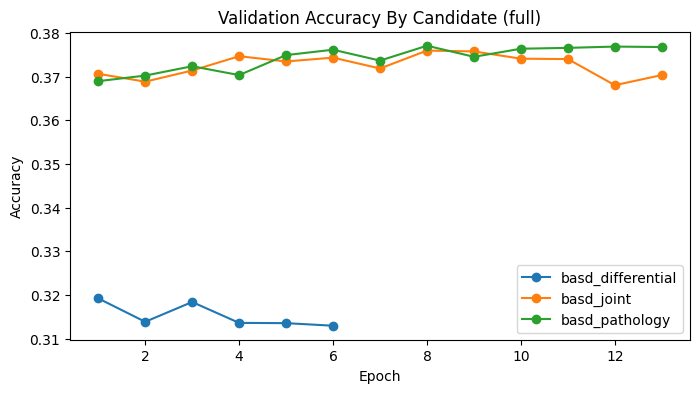

In [7]:
history_frames = []
for row in summary_frame.itertuples(index=False):
    history_path = Path(row.artifact_dir) / "training_history.json"
    history = pd.read_json(history_path)
    history["candidate_name"] = row.candidate_name
    history_frames.append(history)

history_frame = pd.concat(history_frames, ignore_index=True)
display(history_frame.groupby("candidate_name")[["accuracy", "macro_f1"]].max().sort_values("accuracy", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
for candidate_name, group in history_frame.groupby("candidate_name"):
    ax.plot(group["epoch"], group["accuracy"], marker="o", label=candidate_name)
ax.set_title(f"Validation Accuracy By Candidate ({RUN_MODE})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.show()


## Discussion

This notebook intentionally stops at the strongest one-shot baselines. It gives the project a serious non-agentic reference point, but it still uses only the initial visible evidence. The next notebook turns the same case representation into a sequential workup environment so you can measure what additional evidence gathering buys you before adding multi-agent coordination.
